In this notebook, we will explore a linear regression model coupled with Principal Component Analysis (PCA). The idea behind PCA is to find independent linear combinations of input features that explain most of the variance observed in the dataset. Let's start by setting up the code to load the data and split it in training and validation subsets.

In [97]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import *
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression,  Ridge, Lasso
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
import pandas as pd
import seaborn as sns

## Get the dataset as numpy array
data_loc = [
    "./data/full_data.csv",
    # './data/reduced-augmented_shot1e-09_pink7e-08_brown3e-07_snr17.85.csv',
    # './data/reduced-augmented_shot5e-09_pink2e-08_brown8e-08_snr15.58.csv',
]
with_amp = True

if isinstance(data_loc, list):
    data_list = []
    for l in data_loc:
        data_list.append(pd.read_csv(l))
    data = pd.concat(data_list)
else:
    data = pd.read_csv(data_loc)

# drop any columns that contain 'amp'
if with_amp is False:
    amp_cols = data.filter(like='amp').columns
    print(f"Dropping {len(amp_cols)} columns: {amp_cols}")
    data = data.drop(amp_cols, axis=1)

# data = pd.read_csv('data/reduced_data.csv', sep=',')

features = list(data.columns)[1:]
x_data = data.values[:,1:-1]
y_data = data.values[:, -1]
n_features = len(features) - 1

y_norm = -41.9 # largest y dimension to be used to normalize y data

def split_data(split_type='random', labels = []):
    if split_type == 'random':
        X_train, X_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.20, random_state=42)
    if split_type == 'label':
        X_train = data.loc[~data[features[-1]].isin(labels)].values[:, 1:-1]
        X_test = data.loc[data[features[-1]].isin(labels)].values[:, 1:-1]
        y_train =  data.loc[~data[features[-1]].isin(labels)].values[:, -1]
        y_test = data.loc[data[features[-1]].isin(labels)].values[:, -1]    
    
    
    x_mean = np.mean(X_train, axis = 0)
    x_std  = np.std(X_train, axis = 0)
    x_std[x_std == 0] = 1
    X_train = (X_train - x_mean)/x_std
    X_test  = (X_test - x_mean)/x_std
    y_train = y_train/y_norm
    y_test  = y_test/y_norm
    
    return X_train, X_test, y_train, y_test, x_mean, x_std

In [98]:
class CDMS_PCA:
    def __init__(self, X_train, y_train, X_test, y_test, x_mean, x_std, n_components):
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        self.x_mean = x_mean
        self.x_std = x_std
        self.pca = PCA(n_components = n_components)
        self.pca.fit(self.X_train)
        # print("Number of principal components chosen = {}".format(self.pca.n_components_))
    
    def get_components(self):
        return self.pca.components_
    
    def get_ncomponents(self):
        return self.pca.n_components_
    
    def get_variances(self):
        return self.pca.explained_variance_
    
    def get_variance_ratios(self):
        return self.pca.explained_variance_ratio_
    
    def transform(self, X):
        return self.pca.transform(X)
    
    # Zack: calculate per-label rmse
    def calculate_per_label_rmse(self, y_test_pred, y_norm, labels):
        per_label_rmse = {}
        for label in labels:
            mask = (self.y_test == label)
            if np.sum(mask) > 0:
                rmse = np.sqrt(np.mean((self.y_test[mask]*y_norm - y_test_pred[mask]*y_norm)**2))
                per_label_rmse[label*y_norm] = rmse
        return per_label_rmse
    
    def do_LR(self, do_plot=True, mode='LR', alpha=1.0):
        print("Performing Linear regression using principal components and evaluating with test data")
        X_train_pc = self.pca.transform(self.X_train)
        X_test_pc = self.pca.transform(self.X_test)
        print(f"Train Shape PCA: {X_train_pc.shape}")
        print(f"Test Shape PCA: {X_test_pc.data.shape}")
        y_train = self.y_train
        y_test = self.y_test
        if mode == 'LR':
            LR_PCA = LinearRegression().fit(X_train_pc, y_train)
        if mode == 'Ridge':
            LR_PCA = Ridge(alpha=alpha).fit(X_train_pc, y_train)
        if mode == 'Lasso':
            LR_PCA = Lasso(alpha=alpha).fit(X_train_pc, y_train)
        
        y_train_pred_pc = LR_PCA.predict(X_train_pc)
        MSE_train = np.sqrt(np.mean((y_train*y_norm - y_train_pred_pc*y_norm)**2))
        
        y_test_pred_pc = LR_PCA.predict(X_test_pc)
        # Zack: calculate per-label RMSE as well as overall RMSE
        labels_norm = [y for y in np.unique(y_test).tolist()]
        per_label_rmse = self.calculate_per_label_rmse(y_test_pred_pc, y_norm, labels=labels_norm)
        MSE_test = np.sqrt(np.mean((y_test*y_norm - y_test_pred_pc*y_norm)**2))
        
        
        if do_plot:
            print("RMSE from train data = {}".format(MSE_train))
            print("Overall RMSE from test data = {}".format(MSE_test))
            for label, rmse in per_label_rmse.items():
                print("RMSE for y = {:.4f}: {:.4f}".format(label, rmse)) 
                
            fig = plt.figure(figsize=(8,8))
            plt.scatter(y_train*y_norm, y_train_pred_pc*y_norm, marker='x', s=100, color='b', label='Train')
            plt.scatter(y_test*y_norm,  y_test_pred_pc*y_norm, marker='.', color='r', label='Test')
            plt.plot(y_train*y_norm, y_train*y_norm, color='k')
            plt.xlabel("True Value")
            plt.ylabel("Predicted Value")
            plt.legend(fontsize = 20)
            plt.show()
            
        return MSE_train, MSE_test
        

Now we can quickly check how the transformed variables are correlated among themselves.

<Axes: >

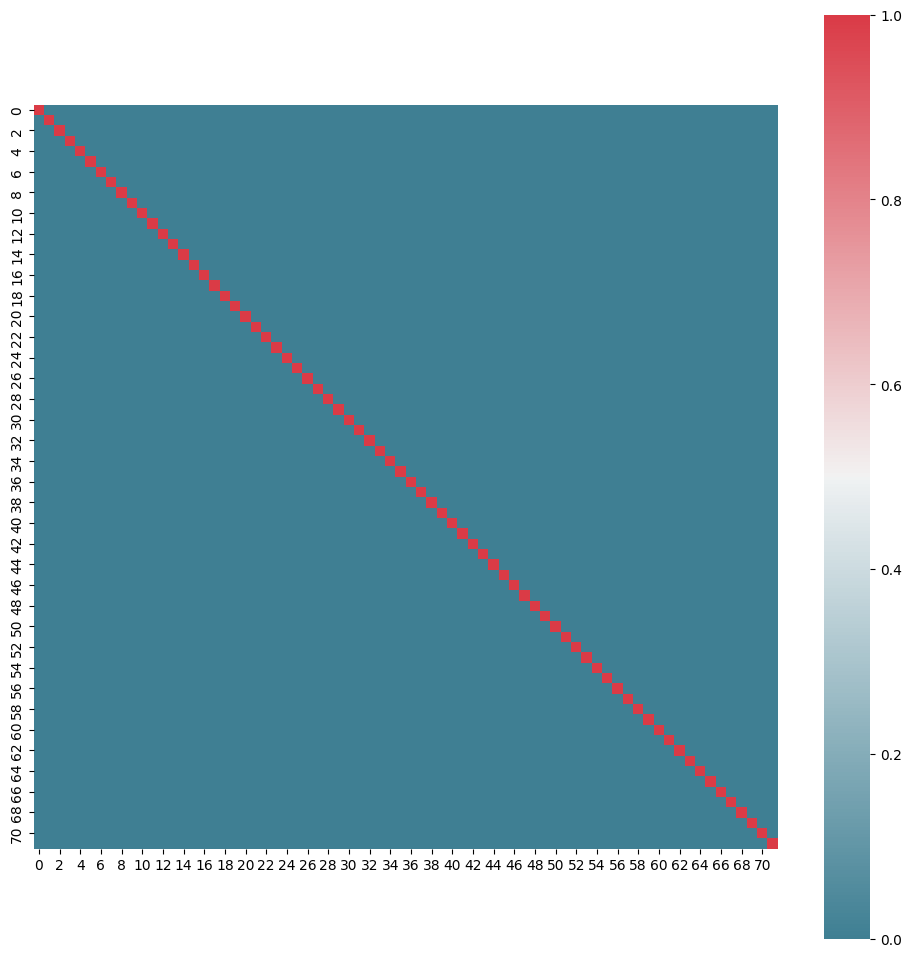

In [99]:
X_train, X_test, y_train, y_test, x_mean, x_std = split_data(split_type='label', 
                                                             labels = [-12.502, -29.5, -41.9])
pca =  CDMS_PCA(X_train, y_train, X_test, y_test, x_mean, x_std, n_components=0.99999)
x_train_trans = pca.transform(X_train)
x_corr = np.corrcoef(x_train_trans, rowvar=False)
f, ax = plt.subplots(figsize=(12,12))
sns.heatmap(x_corr, mask=np.zeros_like(x_corr, dtype=bool),
            cmap=sns.diverging_palette(220, 10, as_cmap=True),
            square=True, ax=ax)

As we can see, the transformed feature space are all pairwise orthogonal, with each off-diagonal element of the correlation matrix being exactly 0. Next, we can check which principal compoent is responsible for what fraction of the observed variances in the feature space.

In [100]:
pca.get_variance_ratios()

array([6.15008534e-01, 2.18405949e-01, 6.95668644e-02, 2.74279560e-02,
       1.44712344e-02, 1.07977040e-02, 8.98194155e-03, 7.86979634e-03,
       3.73163335e-03, 3.33706936e-03, 2.51182479e-03, 1.75670194e-03,
       1.60485972e-03, 1.55084853e-03, 1.28545182e-03, 1.20723592e-03,
       1.01763300e-03, 8.93014850e-04, 8.69583970e-04, 7.28490938e-04,
       6.93325765e-04, 6.41094161e-04, 5.05474431e-04, 4.92686274e-04,
       4.16295150e-04, 3.78550865e-04, 3.19626013e-04, 2.73095966e-04,
       2.68873095e-04, 2.49843931e-04, 2.26820298e-04, 1.97745095e-04,
       1.90070666e-04, 1.65347893e-04, 1.44632090e-04, 1.31527122e-04,
       1.18631324e-04, 1.12570065e-04, 1.06214400e-04, 1.05980850e-04,
       1.01365750e-04, 9.60385039e-05, 9.12805234e-05, 8.75650610e-05,
       7.46297079e-05, 7.27666907e-05, 6.45523629e-05, 6.29052943e-05,
       6.21946958e-05, 5.30129397e-05, 5.09979370e-05, 4.97347994e-05,
       4.59696509e-05, 3.62642125e-05, 3.31895988e-05, 3.21694324e-05,
      

The first principal component alone explains 50% of the variance observed in the feature space, while the last principal component explains only about 0.014% of the variance. Now, we can keep a first few of these and perform a linear regression to see how well it performs. We will choose to keep the components that contribute a total of 90% of the observed variances.

Number of components chosen:  3
Performing Linear regression using principal components and evaluating with test data
Train Shape PCA: (5636, 3)
Test Shape PCA: (1515, 3)
RMSE from train data = 2.4242548275704836
Overall RMSE from test data = 2.5229944650405094
RMSE for y = -12.5020: 3.2607
RMSE for y = -29.5000: 2.6786
RMSE for y = -41.9000: 1.3570


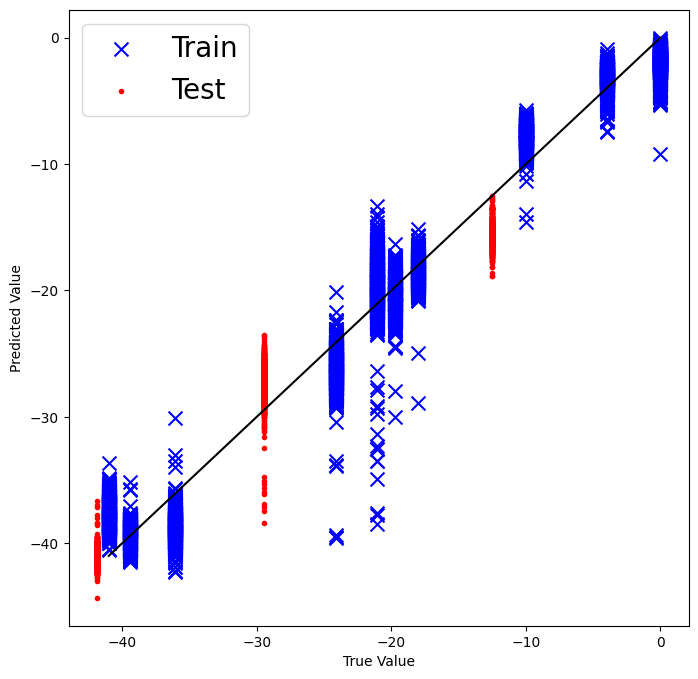

In [101]:
pca =  CDMS_PCA(X_train, y_train, X_test, y_test, x_mean, x_std, n_components=0.9)
print("Number of components chosen: ", pca.get_ncomponents())
rmse_lr_train, rmse_lr_test = pca.do_LR()

Performing Linear regression using principal components and evaluating with test data
Train Shape PCA: (5636, 3)
Test Shape PCA: (1515, 3)
Performing Linear regression using principal components and evaluating with test data
Train Shape PCA: (5636, 3)
Test Shape PCA: (1515, 3)
Performing Linear regression using principal components and evaluating with test data
Train Shape PCA: (5636, 3)
Test Shape PCA: (1515, 3)
Performing Linear regression using principal components and evaluating with test data
Train Shape PCA: (5636, 3)
Test Shape PCA: (1515, 3)
Performing Linear regression using principal components and evaluating with test data
Train Shape PCA: (5636, 3)
Test Shape PCA: (1515, 3)
Performing Linear regression using principal components and evaluating with test data
Train Shape PCA: (5636, 3)
Test Shape PCA: (1515, 3)
Performing Linear regression using principal components and evaluating with test data
Train Shape PCA: (5636, 3)
Test Shape PCA: (1515, 3)
Performing Linear regressio

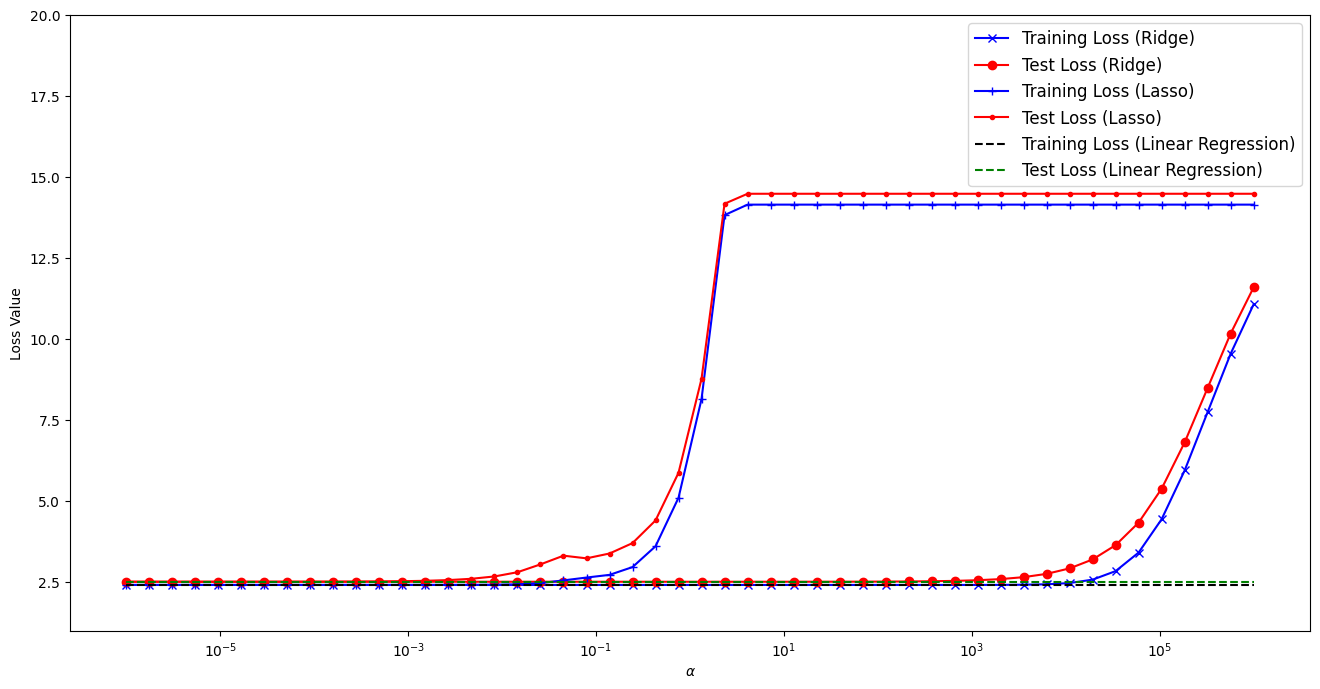

Minimum Test Loss for Ridge:  2.522994465081723
Alpha for Minimum Test Loss for Ridge:  1e-06
Minimum Test Loss for Lasso:  2.523013433376579
Alpha for Minimum Test Loss for Lasso:  1e-06

 BEST RIDGE MODEL
Performing Linear regression using principal components and evaluating with test data
Train Shape PCA: (5636, 3)
Test Shape PCA: (1515, 3)
RMSE from train data = 2.4242548275704836
Overall RMSE from test data = 2.522994465081723
RMSE for y = -12.5020: 3.2607
RMSE for y = -29.5000: 2.6786
RMSE for y = -41.9000: 1.3570


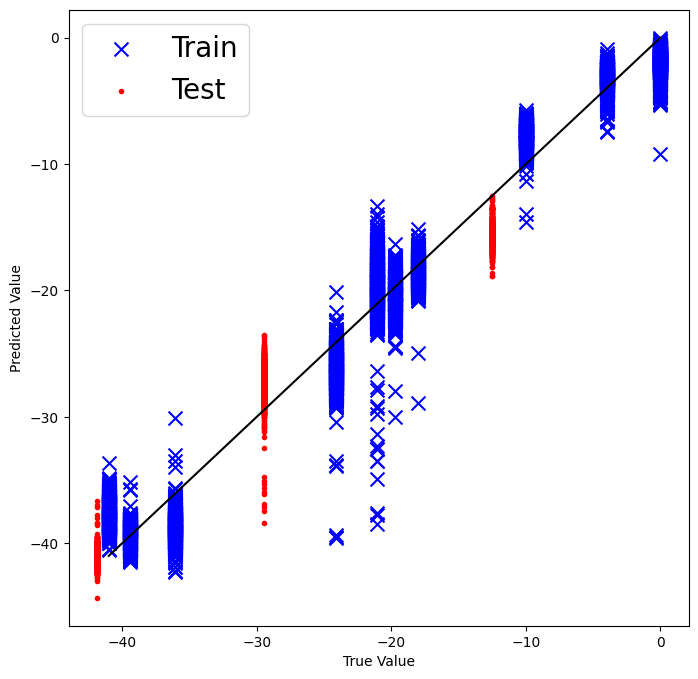


 BEST LASSO MODEL
Performing Linear regression using principal components and evaluating with test data
Train Shape PCA: (5636, 3)
Test Shape PCA: (1515, 3)
RMSE from train data = 2.424254827659193
Overall RMSE from test data = 2.523013433376579
RMSE for y = -12.5020: 3.2608
RMSE for y = -29.5000: 2.6787
RMSE for y = -41.9000: 1.3570


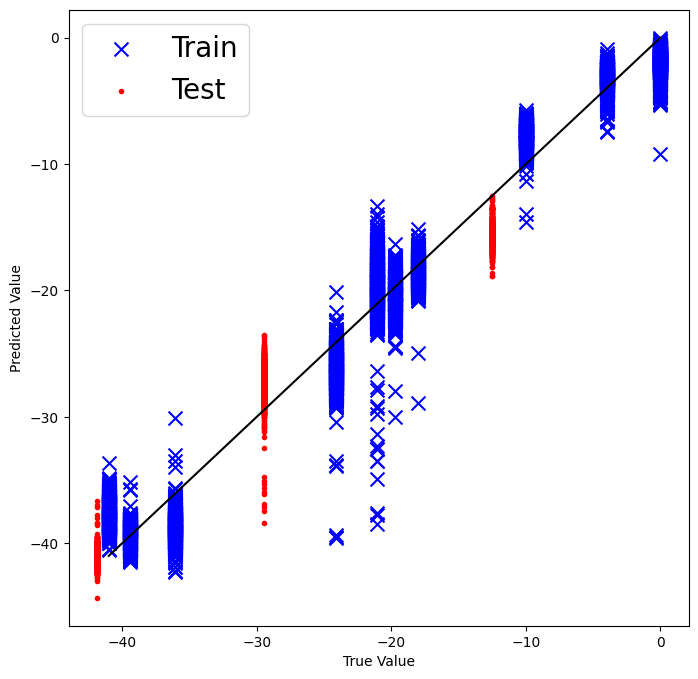

(np.float64(2.424254827659193), np.float64(2.523013433376579))

In [102]:
alphas = np.logspace(-6, +6, 50)
RMSE_train_Ridge = []
RMSE_test_Ridge = []
RMSE_train_Lasso = []
RMSE_test_Lasso = []
min_ridge_loss = 99.0
min_lasso_loss = 99.0
alpha_opt_ridge = 0.
alpha_opt_lasso = 0.
coeffs_opt_ridge = []
coeffs_opt_lasso = []
for ii, alpha in enumerate(alphas):
    lr = CDMS_PCA(X_train, y_train, X_test, y_test, x_mean, x_std, n_components=0.9)
    etr, etst = lr.do_LR(mode="Ridge", alpha=alpha, do_plot=False)
    # etr, etst, coeffs = lr.model_eval(do_plot=False)
    RMSE_train_Ridge.append(etr)
    RMSE_test_Ridge.append(etst)
    if etst < min_ridge_loss:
        min_ridge_loss = etst
        alpha_opt_ridge = alpha
        # coeffs_opt_ridge = coeffs

    lr = CDMS_PCA(X_train, y_train, X_test, y_test, x_mean, x_std, n_components=0.9)
    etr, etst = lr.do_LR(mode="Lasso", alpha=alpha, do_plot=False)
    # etr, etst, coeffs = lr.model_eval(do_plot=False)
    RMSE_train_Lasso.append(etr)
    RMSE_test_Lasso.append(etst)
    if etst < min_lasso_loss:
        min_lasso_loss = etst
        alpha_opt_lasso = alpha
        # coeffs_opt_lasso = coeffs



fig = plt.figure(figsize=(16,8))
plt.plot(alphas, RMSE_train_Ridge, marker='x', color='b', label='Training Loss (Ridge)')
plt.plot(alphas, RMSE_test_Ridge, marker='o',  color='r', label='Test Loss (Ridge)')
plt.plot(alphas, RMSE_train_Lasso, marker='+', color='b', label='Training Loss (Lasso)')
plt.plot(alphas, RMSE_test_Lasso, marker='.', color='r', label='Test Loss (Lasso)')

plt.plot(alphas, [rmse_lr_train]*len(alphas), color='k', linestyle='--', label='Training Loss (Linear Regression)')
plt.plot(alphas, [rmse_lr_test]*len(alphas), color='g', linestyle = '--', label='Test Loss (Linear Regression)')

plt.xscale('log')
plt.xlabel(r'$\alpha$')
plt.ylabel("Loss Value")
plt.legend(fontsize = 12)
plt.ylim([1.0, 20.0])
plt.show()

print("Minimum Test Loss for Ridge: ", min_ridge_loss)
print("Alpha for Minimum Test Loss for Ridge: ", alpha_opt_ridge)

print("Minimum Test Loss for Lasso: ", min_lasso_loss)
print("Alpha for Minimum Test Loss for Lasso: ", alpha_opt_lasso)

print("\n BEST RIDGE MODEL")
best_ridge = CDMS_PCA(X_train, y_train, X_test, y_test, x_mean, x_std, n_components=0.9)
best_ridge.do_LR(mode="Ridge", alpha=alpha_opt_ridge)
# best_ridge.model_eval(do_plot=True)

print("\n BEST LASSO MODEL")
best_lasso = CDMS_PCA(X_train, y_train, X_test, y_test, x_mean, x_std, n_components=0.9)
best_lasso.do_LR(mode="Lasso", alpha=alpha_opt_lasso)
# best_lasso.model_eval(do_plot=True)

In [63]:
Ncomps = list(range(1,n_features+1))
train_losses = []
test_losses = []
for ncomp in Ncomps:
    pca =  CDMS_PCA(X_train, y_train, X_test, y_test, x_mean, x_std, n_components=ncomp)
    train_loss, test_loss = pca.do_LR(do_plot = False)
    train_losses.append(train_loss)
    test_losses.append(test_loss)

Performing Linear regression using principal components and evaluating with test data
Train Shape PCA: (5636, 1)
Test Shape PCA: (1515, 1)
Performing Linear regression using principal components and evaluating with test data
Train Shape PCA: (5636, 2)
Test Shape PCA: (1515, 2)
Performing Linear regression using principal components and evaluating with test data
Train Shape PCA: (5636, 3)
Test Shape PCA: (1515, 3)
Performing Linear regression using principal components and evaluating with test data
Train Shape PCA: (5636, 4)
Test Shape PCA: (1515, 4)
Performing Linear regression using principal components and evaluating with test data
Train Shape PCA: (5636, 5)
Test Shape PCA: (1515, 5)
Performing Linear regression using principal components and evaluating with test data
Train Shape PCA: (5636, 6)
Test Shape PCA: (1515, 6)
Performing Linear regression using principal components and evaluating with test data
Train Shape PCA: (5636, 7)
Test Shape PCA: (1515, 7)
Performing Linear regressio

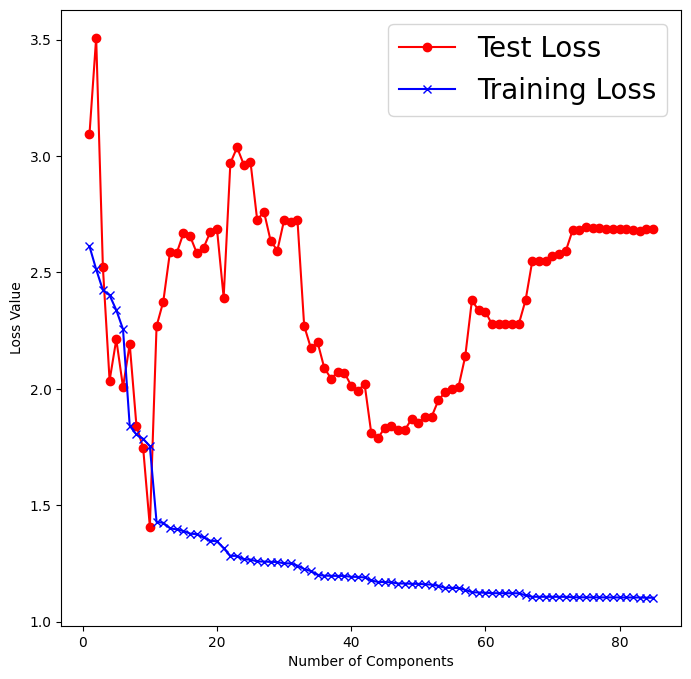

In [64]:
fig = plt.figure(figsize=(8,8))
plt.plot(Ncomps, test_losses, marker='o',  color='r', label='Test Loss')
plt.plot(Ncomps, train_losses, marker='x', color='b', label='Training Loss')
plt.xlabel('Number of Components')
plt.ylabel("Loss Value")
plt.legend(fontsize = 20)
plt.show()


In [14]:
train_losses[15]

1.8481574988464202

I think at this point it can be a great exercise for the students to use the code given in this notebook to develop the model in FAIR way. One can use the previous notebooks on linear regression to see how the directory hierarchy has been built, the code has been organized, and eventually the model has been published.